# Variance-Preserving Forward SDE
We consider a variance-preserving SDE given by 
$$
dX_t = -\frac12 \beta(t) X_t dt + \sqrt{\beta(t)} dW_t
$$
for $0\le t\le 1$, where $W_t$ is the standard Brownian motion with $W_0=0$ a.s. The schedule $\beta(t)$ is chosen so that $\beta(0)=\beta_1$, $\beta(1)=\beta_2$, $0<\beta_1<\beta_2$, increasing in $t$ and $B(t) := \int_0^t \beta(s)\, ds \to\infty$. 


In [3]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

from src.sde import VPSDE
from src.toy_data import two_moons

plt.rcParams["figure.dpi"] = 110
sde = VPSDE()
sde

VPSDE(beta_min=0.1, beta_max=20.0, a=0.008, T=1.0)

We will use the following schedules for this project:
1. $\beta(t) = \beta_1 + (\beta_2 - \beta_1) t^k$ for $k>0$,
2. $\beta(t) = \frac{\pi}{1+a}\tan(\frac{\pi}{2}\frac{t+a}{1+a})$ for small enough $a>0$. In this case, $\beta_1 = \frac{\pi}{1+a}\tan(\frac{\pi}{2}\frac{a}{1+a})$ and $\beta_2=\infty$.

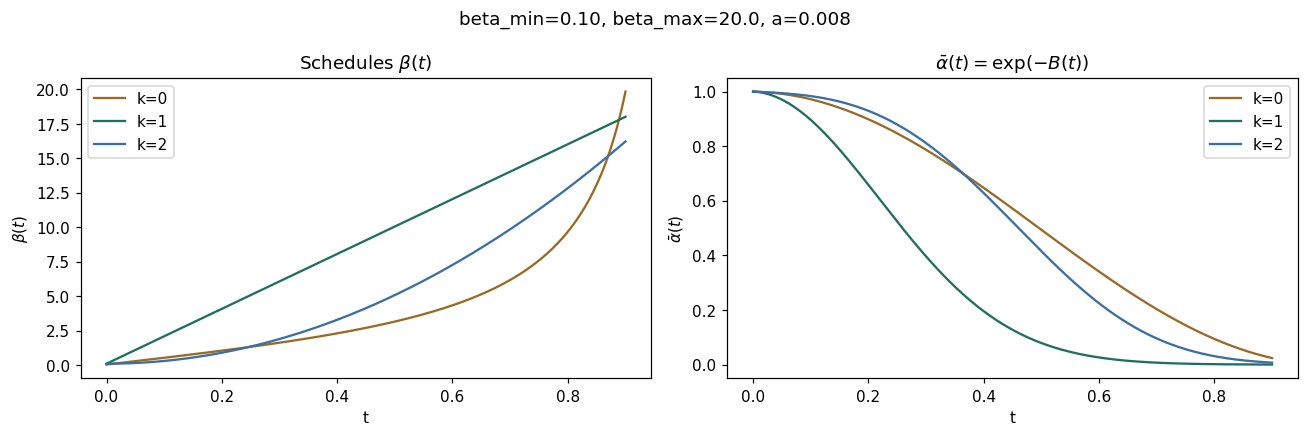

In [4]:
ts = np.linspace(0.0, 0.9, 400)
ks = [0, 1, 2]
colors = {0: "#9a6a25", 1: "#1f6f5c", 2: "#3b6ea5"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for k in ks:
    beta_vals = np.array([sde.beta(float(t), k) for t in ts])
    axes[0].plot(ts, beta_vals, label=f"k={k}", color=colors[k])
axes[0].set_title(r"Schedules $\beta(t)$")
axes[0].set_xlabel("t")
axes[0].set_ylabel(r"$\beta(t)$")
axes[0].legend()

for k in ks:
    B_vals = np.array([sde.beta_int(float(t), k) for t in ts])
    alpha_bar = np.exp(-B_vals)
    axes[1].plot(ts, alpha_bar, label=f"k={k}", color=colors[k])
axes[1].set_title(r"$\bar\alpha(t) = \exp(-B(t))$")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$\bar\alpha(t)$")
axes[1].legend()

fig.suptitle(f"beta_min={sde.beta_min:.2f}, beta_max={sde.beta_max:.1f}, a={sde.a:.3f}")
fig.tight_layout()
plt.savefig("figures/vpsde_schedules.png", dpi=150)
plt.show()

The closed form of the process is $X_t = e^{-\frac12 B(t)}X_0 + \int_0^t \sqrt{\beta(s)} e^{-\frac12 (B(t)-B(s))}\, dW_s$. From this, one can see that $\mathrm{E}[X_t|X_0] = e^{-\frac12 B(t)}X_0$ and $\mathrm{Var}(X_t|X_0) = 1 - e^{-B(t)}$. 

In [5]:
rng = np.random.default_rng(0)

data = two_moons(2000, seed=1)
x0_single = data[12].astype(np.float32)

t_star = float(rng.uniform(0.05, 0.95))
print(f"x0 = {x0_single}")
print(f"randomly chosen t* = {t_star:.4f}")

x0 = [-0.9318909   0.13990566]
randomly chosen t* = 0.6233


In [6]:
n_particles = 20_000
n_steps = 3_000

results = {}
for k in ks:
    x0_batch = np.tile(x0_single, (n_particles, 1)).astype(np.float32)
    rng_traj = np.random.default_rng(100 + k)
    traj, ts_sim = sde.sample_trajectory(
        x0_batch, n_steps=n_steps, rng=rng_traj, k=k, t0=0.0, t1=t_star
    )
    x_traj = traj[-1]

    t_arr = np.array(t_star, dtype=x0_single.dtype)
    mean_cf, var_cf = sde.marginal_dist(x0_single[None, :], t_arr, k)
    mean_cf, std_cf = mean_cf[0], np.sqrt(var_cf[0])

    rng_cf = np.random.default_rng(200 + k)
    x_cf_samples = sde.sample_marginal(
        np.tile(x0_single, (n_particles, 1)).astype(np.float32), t_arr, rng_cf, k
    )

    results[k] = {
        "x_traj": x_traj,
        "x_cf_samples": x_cf_samples,
        "mean_cf": mean_cf,
        "std_cf": std_cf,
    }

    print(f"k={k}:")
    print(f"  simulated (Euler-Maruyama) mean={x_traj.mean(0)}, std={x_traj.std(0)}")
    print(f"  closed-form (marginal_dist) mean={mean_cf}, std={std_cf}")
    print()

k=0:
  simulated (Euler-Maruyama) mean=[-0.51703     0.07575055], std=[0.83033544 0.8337071 ]
  closed-form (marginal_dist) mean=[-0.51620173  0.07749785], std=[0.83256364 0.83256364]

k=1:
  simulated (Euler-Maruyama) mean=[-0.141202    0.01427681], std=[0.99040425 0.9896203 ]
  closed-form (marginal_dist) mean=[-0.13077323  0.01963311], std=[0.9901047 0.9901047]

k=2:
  simulated (Euler-Maruyama) mean=[-0.40822425  0.0522441 ], std=[0.9007465 0.9127724]
  closed-form (marginal_dist) mean=[-0.40465796  0.06075168], std=[0.9008005 0.9008005]



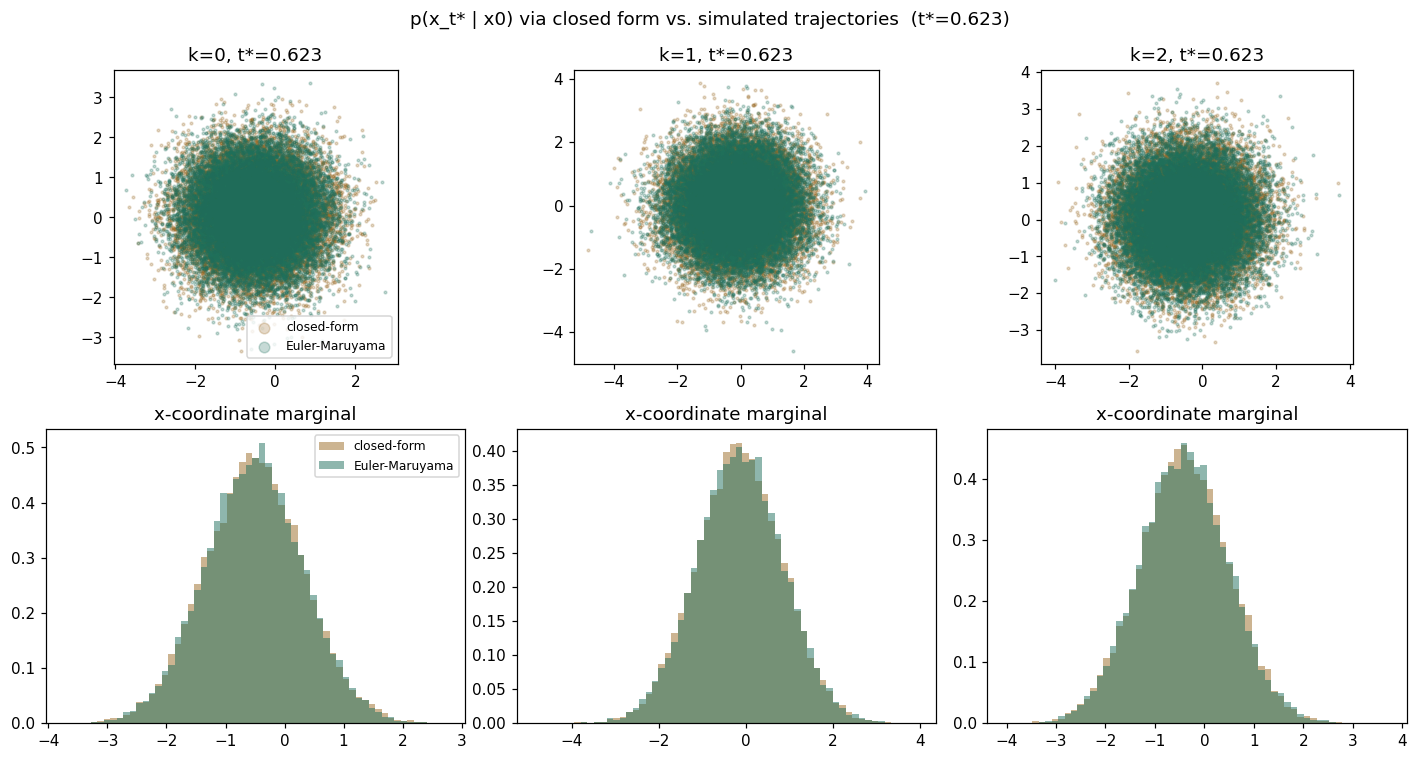

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for col, k in enumerate(ks):
    r = results[k]

    ax = axes[0, col]
    ax.scatter(
        r["x_cf_samples"][:, 0],
        r["x_cf_samples"][:, 1],
        s=3,
        alpha=0.25,
        color="#9a6a25",
        label="closed-form",
    )
    ax.scatter(
        r["x_traj"][:, 0],
        r["x_traj"][:, 1],
        s=3,
        alpha=0.25,
        color="#1f6f5c",
        label="Euler-Maruyama",
    )
    ax.set_title(f"k={k}, t*={t_star:.3f}")
    ax.set_aspect("equal")
    if col == 0:
        ax.legend(markerscale=4, fontsize=8)

    ax2 = axes[1, col]
    lo = min(r["x_traj"][:, 0].min(), r["x_cf_samples"][:, 0].min())
    hi = max(r["x_traj"][:, 0].max(), r["x_cf_samples"][:, 0].max())
    bins = np.linspace(lo, hi, 60)
    ax2.hist(
        r["x_cf_samples"][:, 0],
        bins=bins,
        density=True,
        alpha=0.5,
        color="#9a6a25",
        label="closed-form",
    )
    ax2.hist(
        r["x_traj"][:, 0],
        bins=bins,
        density=True,
        alpha=0.5,
        color="#1f6f5c",
        label="Euler-Maruyama",
    )
    ax2.set_title("x-coordinate marginal")
    if col == 0:
        ax2.legend(fontsize=8)

fig.suptitle(
    f"p(x_t* | x0) via closed form vs. simulated trajectories  (t*={t_star:.3f})"
)
fig.tight_layout()
plt.savefig("figures/vpsde_marginal_vs_trajectory.png", dpi=150)
plt.show()